In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("NFLX.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [3]:
#EDA
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [6]:
#Change Date column datatype to datetime
df['Date']= pd.to_datetime(df['Date'], errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Open       1009 non-null   float64       
 2   High       1009 non-null   float64       
 3   Low        1009 non-null   float64       
 4   Close      1009 non-null   float64       
 5   Adj Close  1009 non-null   float64       
 6   Volume     1009 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 55.3 KB


In [7]:
df = df.sort_values('Date')

In [8]:
df = df.set_index('Date')
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [9]:
ts = df['Adj Close']

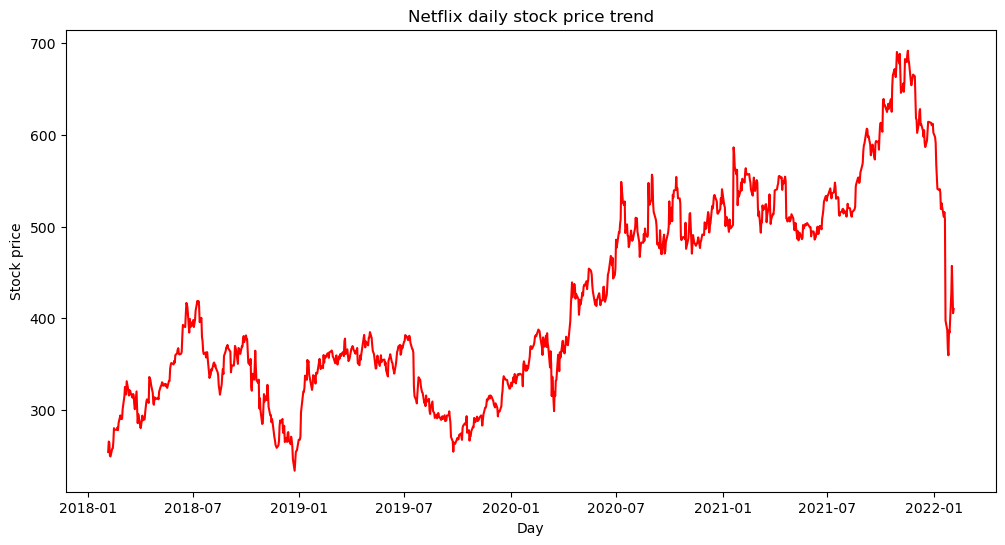

In [11]:
#Plot the original stock price
plt.figure(figsize=(12, 6))
sns.lineplot(x= df.index,y= ts, color = 'red')
plt.title('Netflix daily stock price trend')
plt.xlabel('Day')
plt.ylabel('Stock price')
plt.show()

In [12]:
#Decompose into components
# Seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.datasets import co2

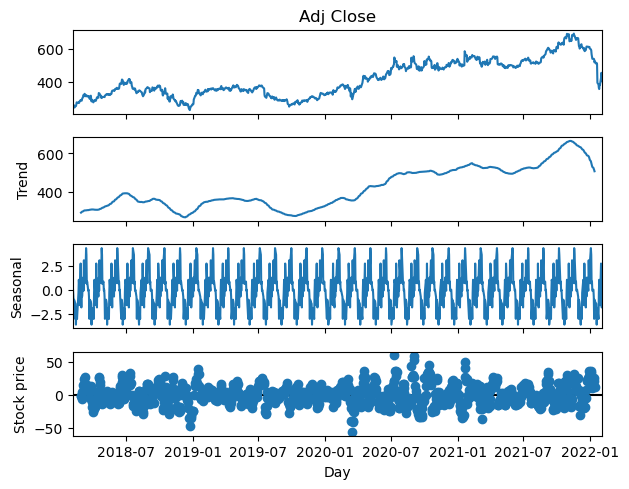

In [18]:
result = seasonal_decompose(ts, model="additive", period=30)
result.plot()
plt.xlabel('Day')
plt.ylabel('Stock price')
plt.show()

In [22]:
#Check for stationarity - Augmented DIckey Fuller test
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test
result = adfuller(ts.dropna())
print(result)
# Print key output metrics
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

(np.float64(-1.8125906878289948), np.float64(0.3742289256820762), 6, 1002, {'1%': np.float64(-3.436893045520188), '5%': np.float64(-2.8644287878535146), '10%': np.float64(-2.568308127138936)}, np.float64(7545.926742057859))
ADF Statistic: -1.8125906878289948
p-value: 0.3742289256820762
Critical Values:
   1%: -3.436893045520188
   5%: -2.8644287878535146
   10%: -2.568308127138936


In [21]:
if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

Not stationary


In [24]:
# Get the rolling standard deviation
rolling_std = ts.rolling(30).std()
print("Avg:",rolling_std.mean())
print("Min:",rolling_std.min())
print("Max:",rolling_std.max())

Avg: 19.352657180509457
Min: 5.449488274826093
Max: 87.85434817586135


In [27]:
# Log transformation
ts_log = np.log(ts)
print(ts_log.head())

Date
2018-02-05    5.538357
2018-02-06    5.582443
2018-02-07    5.578068
2018-02-08    5.521861
2018-02-09    5.519339
Name: Adj Close, dtype: float64


In [28]:
result = adfuller(ts_log.dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value      : {result[1]}")

if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

ADF Statistic: -1.9993209793437463
p-value      : 0.2868709054083399
Not stationary


In [29]:
#First order difference
t1 = ts_log.diff().dropna()
r = adfuller(t1)
print(f"ADF Statistic: {r[0]}")
print(f"p-value      : {r[1]}")

if r[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

ADF Statistic: -14.383890481981506
p-value      : 9.057259523484407e-27
The series is stationary


In [30]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

train_size = int(len(ts_log)*0.80)

train_log = ts_log.iloc[:train_size]
test_log = ts_log.iloc[train_size:]
print("Train length:",len(train_log))
print("Test length:",len(test_log))

Train length: 807
Test length: 202


In [33]:
train,test=train_test_split(
    ts_log,
    test_size=len(test_log),
    shuffle=False
)
print(train)
print(test)

Date
2018-02-05    5.538357
2018-02-06    5.582443
2018-02-07    5.578068
2018-02-08    5.521861
2018-02-09    5.519339
                ...   
2021-04-14    6.291606
2021-04-15    6.308499
2021-04-16    6.303607
2021-04-19    6.317959
2021-04-20    6.309136
Name: Adj Close, Length: 807, dtype: float64
Date
2021-04-21    6.232252
2021-04-22    6.232016
2021-04-23    6.225647
2021-04-26    6.234999
2021-04-27    6.225647
                ...   
2022-01-31    6.057112
2022-02-01    6.124968
2022-02-02    6.062575
2022-02-03    6.005367
2022-02-04    6.016572
Name: Adj Close, Length: 202, dtype: float64


In [38]:
p_val=range(1,6)
q_val=range(1,6)

combi=list(itertools.product(p_val,q_val))

res=[]
for p,q in combi:
    model = ARIMA(train_log,order=(p,1,q))
    m_f=model.fit()

    p_log=m_f.forecast(len(test_log))

    #Convert preditions into original scale
    predictions = np.exp(p_log)

    #Convert to series with dates
    predictions = pd.Series(
        predictions.to_numpy(),
        index = test_log.index
    )
    
    test = np.exp(test_log)

    #rmse - Root mean-squared error
    rmse = root_mean_squared_error(test, predictions)
    res.append({'p': p, 'd':1,'q': q, 'RMSE': rmse})

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `sta

In [42]:
results_df = pd.DataFrame(res, columns = ['p','d','q','RMSE'])
#results_df['d']= 2
results_df.sort_values(by='RMSE', ascending=True, inplace=True)
results_df.head()

,p,d,q,RMSE
23,5,1,4,70.600419
19,4,1,5,70.655846
6,2,1,2,70.670271
8,2,1,4,70.686023
11,3,1,2,70.686755


In [43]:
best = results_df.iloc[0]
best_p = int(best['p'])
best_d = int(best['d'])
best_q = int(best['q'])

model = ARIMA(train_log, order = (best_p,best_d,best_q))
model_fit = model.fit()

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

In [44]:
predictions_log=model_fit.forecast(len(test_log))

  # Convert predictions into original scale
predictions=np.exp(predictions_log)

  # convert to series with dates
predictions=pd.Series(
      predictions.to_numpy(),
      index=test_log.index
  )
test = np.exp(test_log)

  # RMSE
rmse=np.sqrt(
      mean_squared_error(test,predictions)
  )

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [45]:
#Actual vs Predicted
comp = pd.DataFrame({'Actual':test,'Predictions':predictions})
comp

,Actual,Predictions
Date,,
2021-04-21,508.899994,551.610887
2021-04-22,508.779999,551.588279
2021-04-23,505.549988,552.721479
2021-04-26,510.299988,552.813830
2021-04-27,505.549988,552.941470
...,...,...
2022-01-31,427.140015,552.137210
2022-02-01,457.130005,552.137210
2022-02-02,429.480011,552.137210


In [54]:
#Final model
final_model = ARIMA(ts_log, order= (best_p,best_d,best_q))
model_fit = final_model.fit()

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

In [55]:
forecast_log=model_fit.forecast(30)

  # Convert predictions into original scale
forecast=np.exp(forecast_log)

  # convert to series with dates - bdate_range: business date range
future_dates=pd.bdate_range(
    start = ts.index[-1] + pd.Timedelta(days=1),
    periods = 30
)
forecast=pd.Series(forecast.to_numpy(),index=future_dates)

print('30 Forecasted Values: ')
print(forecast)

30 Forecasted Values: 
2022-02-07    402.438754
2022-02-08    396.329716
2022-02-09    393.262852
2022-02-10    390.307641
2022-02-11    391.265592
2022-02-14    393.456228
2022-02-15    396.329938
2022-02-16    400.134718
2022-02-17    402.328746
2022-02-18    403.831216
2022-02-21    403.850599
2022-02-22    402.501024
2022-02-23    400.876046
2022-02-24    398.815489
2022-02-25    397.301469
2022-02-28    396.478455
2022-03-01    396.303763
2022-03-02    396.952948
2022-03-03    397.904198
2022-03-04    399.012435
2022-03-07    399.972036
2022-03-08    400.501453
2022-03-09    400.648959
2022-03-10    400.356882
2022-03-11    399.807945
2022-03-14    399.186423
2022-03-15    398.616459
2022-03-16    398.268966
2022-03-17    398.160396
2022-03-18    398.285860
Freq: B, dtype: float64


C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


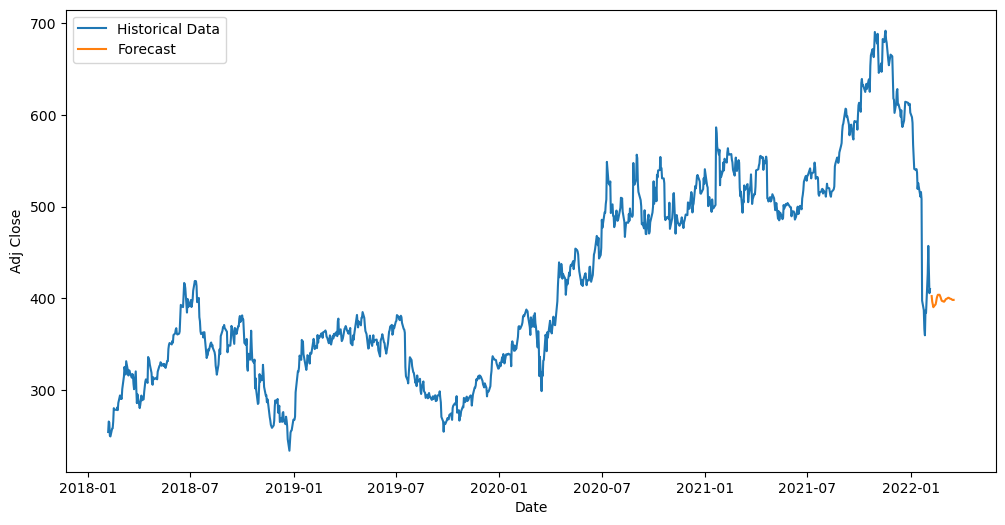

In [58]:
plt.figure(figsize = (12,6))
plt.plot(ts, label = "Historical Data")
plt.plot(forecast, label = "Forecast")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.show()